# White Blood Cell Segmentation: K-Means vs Fuzzy C-Means
**Task:** Segment WBC nucleus and cytoplasm.
**Dataset:** Kaggle — Blood Cell Images
**Objective:** Compare K-means (Hard Clustering) and Fuzzy C-Means (Soft Clustering) to evaluate boundary accuracy between the background, cytoplasm, and nucleus.


In [ ]:
# Install scikit-fuzzy for FCM
!pip install scikit-fuzzy

# Import required libraries
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import skfuzzy as fuzz
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 13.9 MB/s eta 0:00:00
Mounted at /content/drive


## 1. Data Loading and Preprocessing
We will load a sample White Blood Cell image, convert it to RGB (since OpenCV loads as BGR), and reshape it into a 2D array of pixels. Each pixel will be treated as a data point in 3D color space $(R, G, B)$ for the clustering algorithms.

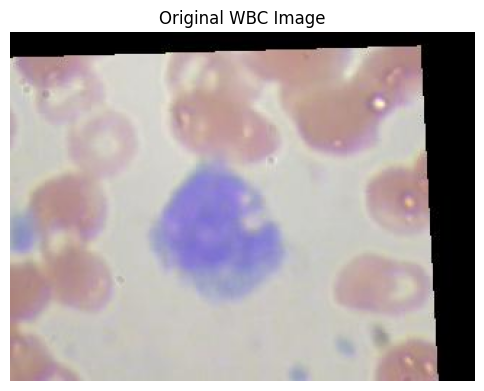

In [ ]:
# Define the path to a specific image in your Drive
# Replace 'Monocyte' and the filename with an actual image path from your uploaded data
BASE_PATH = '/content/drive/MyDrive/MONOCYTE'
sample_image_name = os.listdir(BASE_PATH)[0]
img_path = os.path.join(BASE_PATH, sample_image_name)

# Load image and convert BGR to RGB
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Reshape the image to a 2D array of pixels: (Number_of_Pixels, 3_Color_Channels)
pixel_values = img_rgb.reshape((-1, 3))
pixel_values = np.float32(pixel_values)

plt.figure(figsize=(6,6))
plt.imshow(img_rgb)
plt.title("Original WBC Image")
plt.axis('off')
plt.show()

## 2. K-Means Clustering (Hard Clustering)
K-Means strictly assigns each pixel to exactly one of $k$ clusters. We set $k=3$ expecting the algorithm to find: (1) Background, (2) Cytoplasm, and (3) Nucleus. Because it is a "hard" assignment, the boundaries are sharp but can be jagged or inaccurate if pixel colors blend.

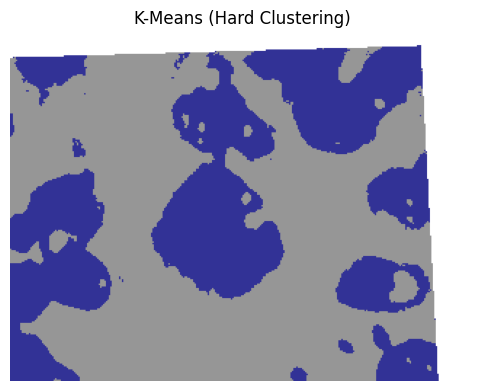

In [ ]:
# Define criteria and apply K-Means
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(pixel_values)

# Get the labels and reshape back to the original image dimensions
kmeans_labels = kmeans.labels_
kmeans_segmented = kmeans_labels.reshape(img_rgb.shape[:2])

# Map labels to distinct colors for visualization
kmeans_colors = np.array([[255, 255, 255], [150, 150, 150], [50, 50, 150]]) # Fake colors for distinction
kmeans_result = kmeans_colors[kmeans_segmented].astype(np.uint8)

plt.figure(figsize=(6,6))
plt.imshow(kmeans_result)
plt.title("K-Means (Hard Clustering)")
plt.axis('off')
plt.show()

## 3. Fuzzy C-Means (Soft Clustering)
Unlike K-Means, Fuzzy C-Means (FCM) assigns a *probability* (membership grade) to each pixel for every cluster. A pixel on the boundary of the nucleus and cytoplasm might belong 60% to the nucleus and 40% to the cytoplasm. This "soft" clustering creates smoother, more accurate boundaries, especially in microscopic images where dye gradients exist.

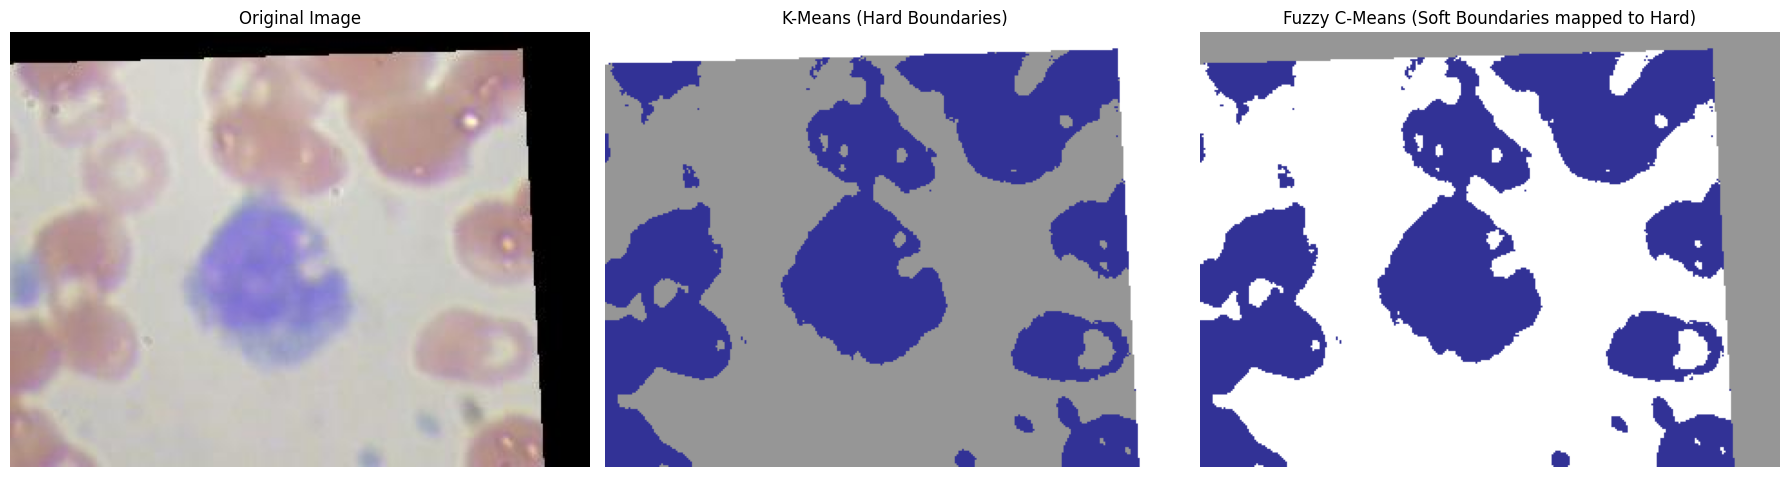

In [ ]:
# skfuzzy requires data in shape (features, N), so we transpose our pixel array
fcm_data = pixel_values.T

# Apply Fuzzy C-Means
# c = number of clusters (3), m = degree of fuzziness (usually 2.0)
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    fcm_data, c=k, m=2.0, error=0.005, maxiter=1000, init=None
)

# u is the membership matrix. We take the argmax to get the final hard boundary for visualization
fcm_labels = np.argmax(u, axis=0)
fcm_segmented = fcm_labels.reshape(img_rgb.shape[:2])

# Map labels to distinct colors for visualization
fcm_result = kmeans_colors[fcm_segmented].astype(np.uint8)

# Visualization Comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img_rgb)
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(kmeans_result)
axes[1].set_title("K-Means (Hard Boundaries)")
axes[1].axis('off')

axes[2].imshow(fcm_result)
axes[2].set_title("Fuzzy C-Means (Soft Boundaries mapped to Hard)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

## 4. Conclusion: Hard vs Soft Clustering & Boundary Accuracy
Conclusion: Hard vs. Soft Clustering and Boundary Accuracy
In segmenting the white blood cell components, the distinction between K-Means (hard clustering) and Fuzzy C-Means (soft clustering) fundamentally alters boundary accuracy. Microscopic images naturally contain transition zones due to chromatic aberration, cell overlap, and gradient dye absorption between the dense nucleus and the lighter cytoplasm. K-Means struggles with these gradients, enforcing a binary inclusion/exclusion rule that frequently results in jagged, anatomically inaccurate artifacts at the cell borders. Conversely, Fuzzy C-Means addresses this by assigning a continuous membership probability to each pixel. This soft clustering paradigm accurately models the transitional uncertainty at the nucleus-cytoplasm interface. While both algorithms eventually require a threshold to produce a final mask, the underlying probabilistic evaluation of FCM generates a significantly smoother, more biologically accurate boundary preservation, reducing the misclassification of edge pixels commonly seen in K-Means.